In [4]:
#cell 1___________________________________________________________________________________
# Imports and Configuration

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

RAW = "../data/raw/"
OUT = "../outputs/charts/"

In [5]:
#cell 2___________________________________________________________________________________
#Load the Data (smart/fast)

cols = ['REF_DATE', 'GEO', 'Labour force characteristics', 'Gender', 'Age group', 'VALUE']

df_raw = pd.read_csv(RAW + "14100017.csv", usecols=cols)
df_raw['date'] = pd.to_datetime(df_raw['REF_DATE'])

print(f"Rows loaded: {len(df_raw):,}")
print(f"Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")

Rows loaded: 4,392,300
Date range: 1976-01-01 00:00:00 to 2026-05-01 00:00:00


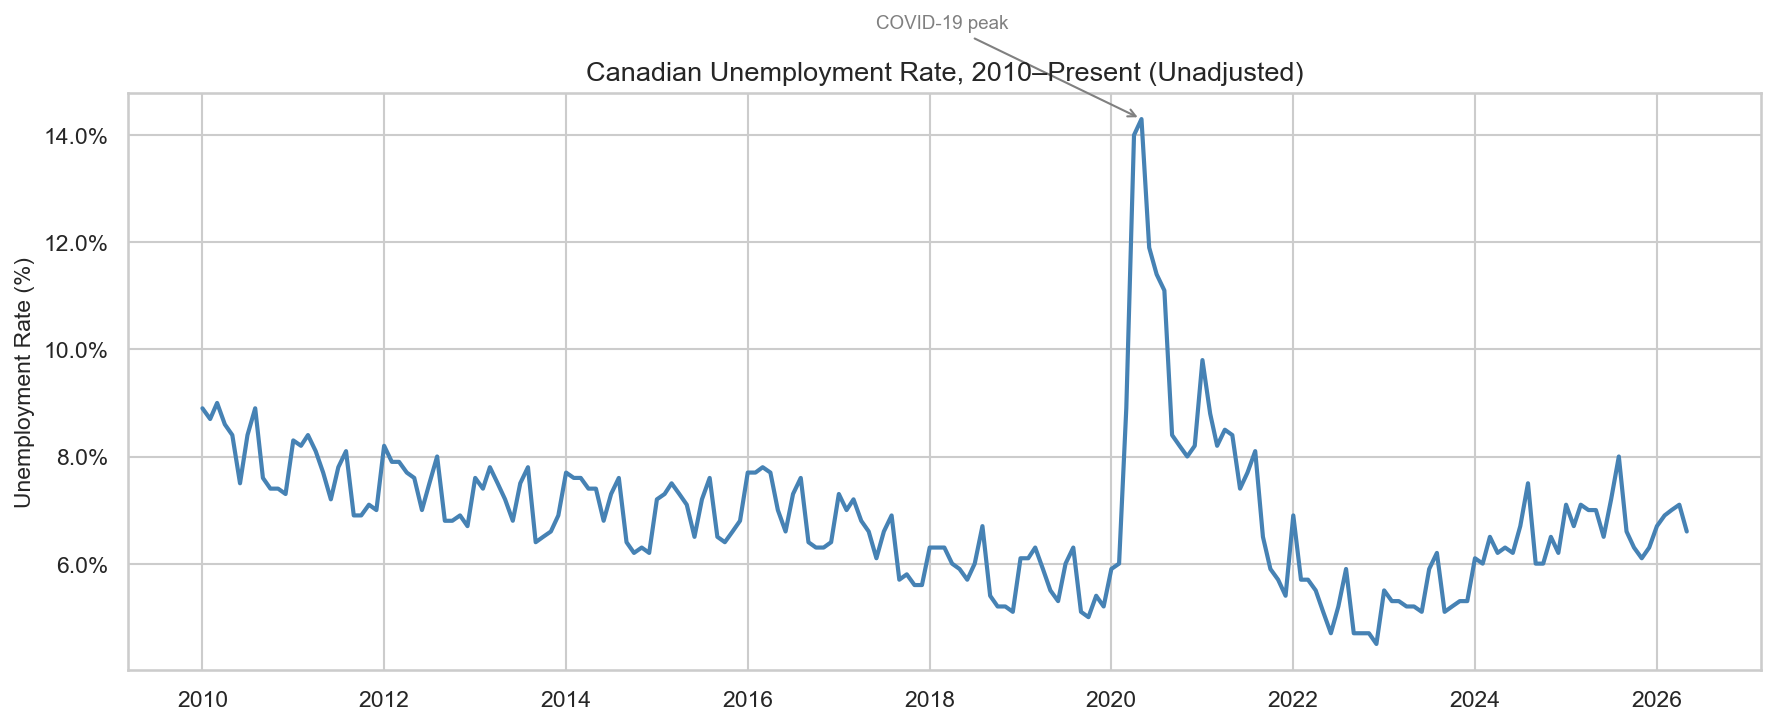

Saved.


In [6]:
#cell 3___________________________________________________________________________________
#Chart 1: National Unemployment Rate Over Time

mask = (
    (df_raw['GEO'] == 'Canada') &
    (df_raw['Gender'] == 'Total - Gender') &
    (df_raw['Age group'] == '15 years and over') &
    (df_raw['Labour force characteristics'] == 'Unemployment rate') &
    (df_raw['date'] >= '2010-01-01')
)

df_unemp = df_raw[mask].sort_values('date')

fig, ax = plt.subplots()
ax.plot(df_unemp['date'], df_unemp['VALUE'], color='steelblue', linewidth=2)

ax.annotate('COVID-19 peak',
            xy=(pd.Timestamp('2020-05-01'), df_unemp[df_unemp['date']=='2020-05-01']['VALUE'].values[0]),
            xytext=(pd.Timestamp('2017-06-01'), 16),
            arrowprops=dict(arrowstyle='->', color='grey'),
            fontsize=9, color='grey')

ax.set_title("Canadian Unemployment Rate, 2010–Present (Unadjusted)")
ax.set_ylabel("Unemployment Rate (%)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=1))

plt.tight_layout()
plt.savefig(OUT + "01_national_unemployment.png")
plt.show()
print("Saved.")

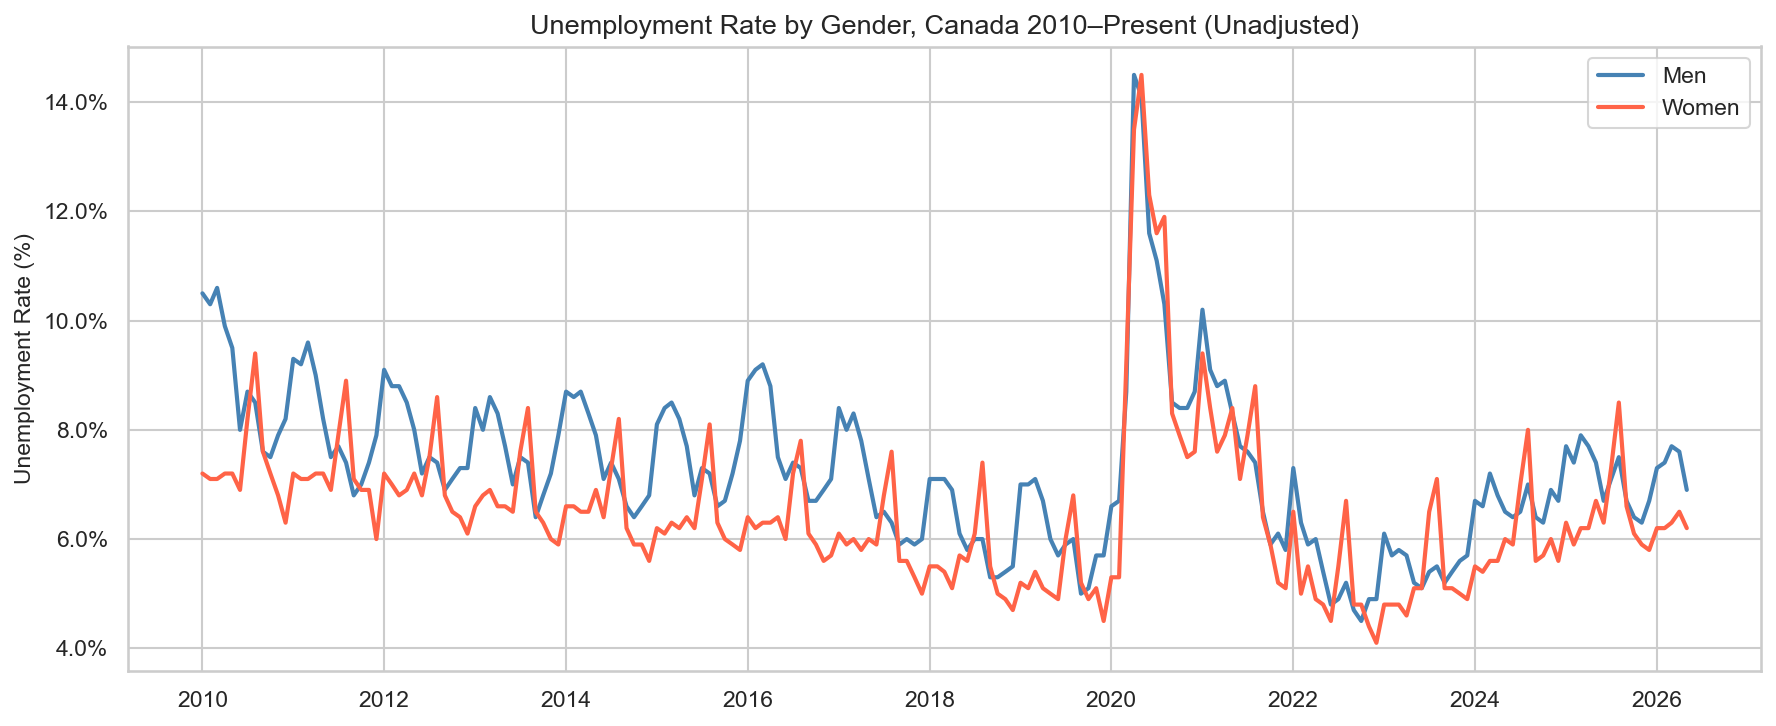

Saved.


In [7]:
#cell 4___________________________________________________________________________________
#Chart 2: Unemployment by Gender (2010–Present)

fig, ax = plt.subplots()

for gender, color, label in [
    ('Men+', 'steelblue', 'Men'),
    ('Women+', 'tomato', 'Women')
]:
    mask_g = (
        (df_raw['GEO'] == 'Canada') &
        (df_raw['Gender'] == gender) &
        (df_raw['Age group'] == '15 years and over') &
        (df_raw['Labour force characteristics'] == 'Unemployment rate') &
        (df_raw['date'] >= '2010-01-01')
    )
    df_g = df_raw[mask_g].sort_values('date')
    ax.plot(df_g['date'], df_g['VALUE'], color=color, linewidth=2, label=label)

ax.set_title("Unemployment Rate by Gender, Canada 2010–Present (Unadjusted)")
ax.set_ylabel("Unemployment Rate (%)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=1))

plt.tight_layout()
plt.savefig(OUT + "02_unemployment_by_gender.png")
plt.show()
print("Saved.")

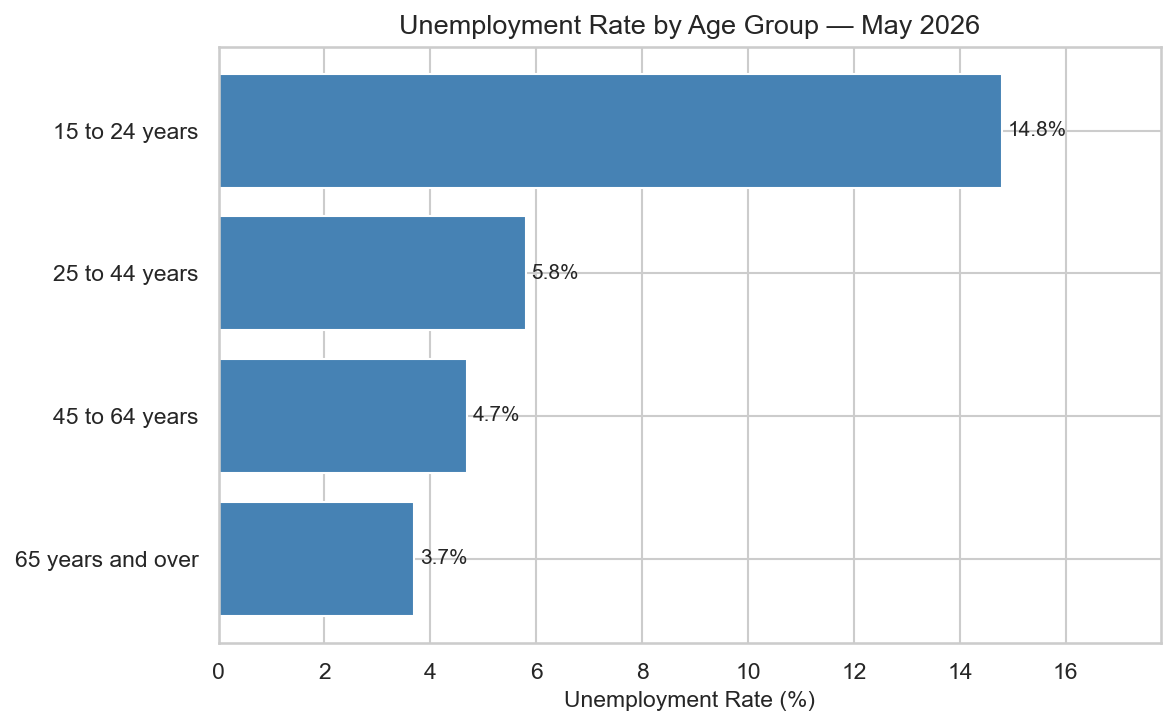

Saved.


In [8]:
#cell 5___________________________________________________________________________________
#Chart 3: Unemployment by Age Group (Latest Month)

age_groups = [
    '15 to 24 years',
    '25 to 44 years',
    '45 to 64 years',
    '65 years and over'
]

latest = df_raw['date'].max()

mask_age = (
    (df_raw['GEO'] == 'Canada') &
    (df_raw['Gender'] == 'Total - Gender') &
    (df_raw['Age group'].isin(age_groups)) &
    (df_raw['Labour force characteristics'] == 'Unemployment rate') &
    (df_raw['date'] == latest)
)

df_age = df_raw[mask_age][['Age group', 'VALUE']].sort_values('VALUE')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(df_age['Age group'], df_age['VALUE'], color='steelblue')

for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va='center', fontsize=10)

ax.set_title(f"Unemployment Rate by Age Group — {latest.strftime('%B %Y')}")
ax.set_xlabel("Unemployment Rate (%)")
ax.set_xlim(0, df_age['VALUE'].max() + 3)

plt.tight_layout()
plt.savefig(OUT + "03_unemployment_by_age.png")
plt.show()
print("Saved.")

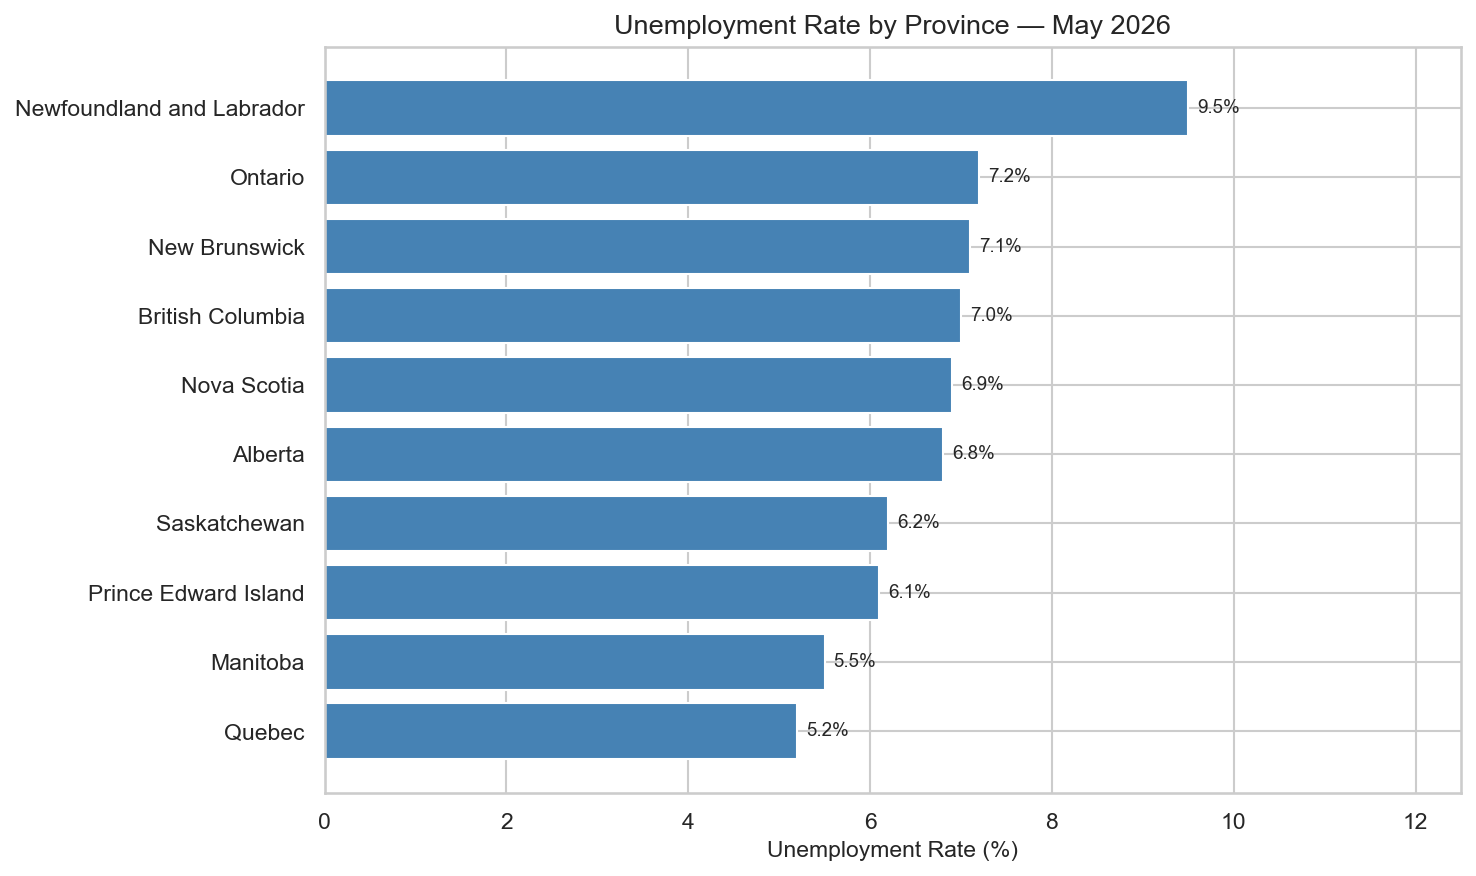

Saved.


In [9]:
#cell 6___________________________________________________________________________________
#Chart 4: Provincial Unemployment (Latest Month)

provinces = [
    'Ontario', 'Quebec', 'British Columbia', 'Alberta',
    'Manitoba', 'Saskatchewan', 'Nova Scotia',
    'New Brunswick', 'Newfoundland and Labrador',
    'Prince Edward Island'
]

mask_prov = (
    (df_raw['GEO'].isin(provinces)) &
    (df_raw['Gender'] == 'Total - Gender') &
    (df_raw['Age group'] == '15 years and over') &
    (df_raw['Labour force characteristics'] == 'Unemployment rate') &
    (df_raw['date'] == latest)
)

df_prov = df_raw[mask_prov][['GEO', 'VALUE']].sort_values('VALUE')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_prov['GEO'], df_prov['VALUE'], color='steelblue')

for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va='center', fontsize=9)

ax.set_title(f"Unemployment Rate by Province — {latest.strftime('%B %Y')}")
ax.set_xlabel("Unemployment Rate (%)")
ax.set_xlim(0, df_prov['VALUE'].max() + 3)

plt.tight_layout()
plt.savefig(OUT + "04_provincial_unemployment.png")
plt.show()
print("Saved.")

In [10]:
#cell 7___________________________________________________________________________________
#Chart 4: Provincial Unemployment (Latest Month)

indicators = ['Unemployment rate', 'Participation rate', 'Employment rate']

mask_sum = (
    (df_raw['GEO'] == 'Canada') &
    (df_raw['Gender'] == 'Total - Gender') &
    (df_raw['Age group'] == '15 years and over') &
    (df_raw['Labour force characteristics'].isin(indicators)) &
    (df_raw['date'] == latest)
)

df_sum = df_raw[mask_sum][['Labour force characteristics', 'VALUE']].set_index('Labour force characteristics')
df_sum.columns = [latest.strftime('%B %Y')]
df_sum

,May 2026
Labour force characteristics,
Unemployment rate,6.6
Participation rate,65.7
Employment rate,61.3
